In [1]:
import scipy
print(scipy.__version__)

1.13.1


In [2]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

# Example data
points = np.array([[0, 0], [1, 0], [0, 1]])
values = np.array([0, 1, 1])
interp = LinearNDInterpolator(points, values)

print(interp(0.5, 0.5))  # Should return an interpolated value


1.0


In [ ]:
from Mixstable.evaluation import compare_methods_across_configs

parameter_configs = {
    "Config1": {"alpha": 0.8, "beta": 0.5, "gamma": 1.0, "delta": 0.0},
    "Config2": {"alpha": 1.5, "beta": -0.2, "gamma": 0.8, "delta": 0.8},
    "Config3": {"alpha": 0.5, "beta": 0.0, "gamma": 1.2, "delta": -0.5},
    "Config4": {"alpha": 1.2, "beta": 0.3, "gamma": 1.1, "delta": 0.2}
}
# Génère un tableau comparatif sur N jeux de données simulées
results = compare_methods_across_configs(parameter_configs, n=100, trials=30)
import pandas as pd
df_results = pd.DataFrame.from_dict(results, orient="index")
print(df_results)
df_results.to_latex("table_performances.tex", index=True)

Running: Config1
Running: Config2
Running: Config3
Running: Config4
         McCulloch       ECF       MLE
Config1        NaN  1.008395       NaN
Config2        NaN  0.221386  0.063826
Config3        NaN  0.685505  0.042673
Config4   0.554555  0.465593  0.052278


true_params before ensure_list_of_dicts: <class 'list'> [{'alpha': 1.590494341909509, 'beta': -0.19007155386774, 'gamma': 1.8697952101533926, 'delta': -1.5682278543170112, 'pi': np.float64(0.5020848971846787)}, {'alpha': 1.4773375638975843, 'beta': -0.43836392693778947, 'gamma': 0.7740600771659707, 'delta': -0.9794126966073091, 'pi': np.float64(0.4979151028153213)}]
true_params after ensure_list_of_dicts: <class 'list'> [{'alpha': 1.590494341909509, 'beta': -0.19007155386774, 'gamma': 1.8697952101533926, 'delta': -1.5682278543170112, 'pi': np.float64(0.5020848971846787)}, {'alpha': 1.4773375638975843, 'beta': -0.43836392693778947, 'gamma': 0.7740600771659707, 'delta': -0.9794126966073091, 'pi': np.float64(0.4979151028153213)}]
est1 raw output: <class 'dict'> {'alpha': np.float64(1.180591468440595), 'beta': np.float64(0.18842990687619807), 'gamma': np.float64(1.2541968210989631), 'delta': np.float64(0.031910908592582124)}
est_params1 after ensure_list_of_dicts: <class 'list'> [{'alpha':

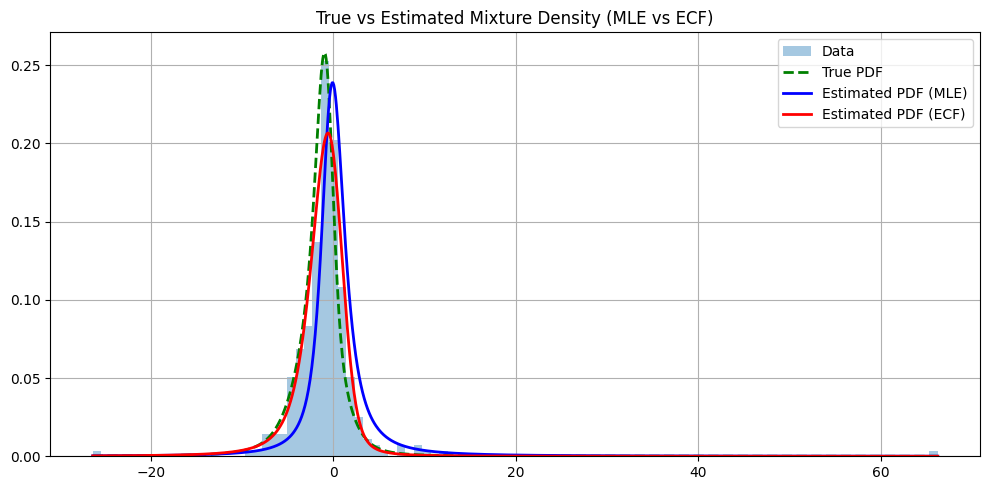

In [ ]:
from Mixstable.visualization import plot_fit_vs_true_methods
from Mixstable.generate_sample import generate_mixture_data

data, true_params = generate_mixture_data(2,300)
plot_fit_vs_true_methods(data, true_params, method1="MLE", method2="ECF")

Iteration 0: Log-Likelihood = -1754.259869
Iteration 1: Log-Likelihood = -1762.182284
Iteration 2: Log-Likelihood = -1753.373175
Iteration 3: Log-Likelihood = -1752.733011
Iteration 4: Log-Likelihood = -1752.017431
Iteration 5: Log-Likelihood = -1751.811041
Iteration 6: Log-Likelihood = -1751.135389
Iteration 7: Log-Likelihood = -1750.767269
Iteration 8: Log-Likelihood = -1750.487881
Iteration 9: Log-Likelihood = -1750.015665
Iteration 10: Log-Likelihood = -1749.658297
Iteration 11: Log-Likelihood = -1749.343412
Iteration 12: Log-Likelihood = -1748.883762
Iteration 13: Log-Likelihood = -1748.524811
Iteration 14: Log-Likelihood = -1748.083828
Iteration 15: Log-Likelihood = -1749.227216
Iteration 16: Log-Likelihood = -1747.465922
Iteration 17: Log-Likelihood = -1747.305874
Converged.


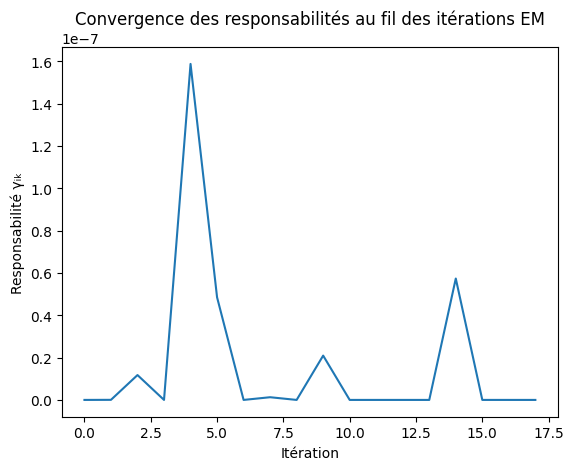

In [ ]:
from Mixstable.em import em_fit_alpha_stable_mixture
from Mixstable.generate_sample import generate_mixture_data
import matplotlib.pyplot as plt

data, _ = generate_mixture_data(2, 1000)
_, _, _, responsibilities_trace,_ = em_fit_alpha_stable_mixture(data, return_trace=True)

plt.plot([r[0][0] for r in responsibilities_trace])  # Example for the first observation and first component
plt.xlabel("Itération")
plt.ylabel("Responsabilité γᵢₖ")
plt.title("Convergence des responsabilités au fil des itérations EM")
plt.show()

In [ ]:
from Mixstable.evaluation import compare_em_vs_em_gibbs
from Mixstable.generate_sample import generate_mixture_data

data, true_params = generate_mixture_data(2, 20)
df_em_comparison = compare_em_vs_em_gibbs(data=data, n_runs=20)
print(df_em_comparison)
df_em_comparison.to_latex("table_em_vs_gibbs.tex", index=False)


Iteration 0: Log-Likelihood = -44.600680
Iteration 1: Log-Likelihood = -44.600680
Converged.
[Gibbs EM] Iteration 0: Log-Likelihood = -44.820891
⚠️ Cluster 1 too small. Reusing previous estimate.
[Gibbs EM] Iteration 1: Log-Likelihood = -55.433571
⚠️ Cluster 0 too small. Reusing previous estimate.
[Gibbs EM] Iteration 2: Log-Likelihood = -61.533585
⚠️ Cluster 1 too small. Reusing previous estimate.
[Gibbs EM] Iteration 3: Log-Likelihood = -79.560661
⚠️ Cluster 0 too small. Reusing previous estimate.
[Gibbs EM] Iteration 4: Log-Likelihood = -125.435821
⚠️ Cluster 1 too small. Reusing previous estimate.
[Gibbs EM] Iteration 5: Log-Likelihood = -87.065816
⚠️ Cluster 0 too small. Reusing previous estimate.
[Gibbs EM] Iteration 6: Log-Likelihood = -50.167201
⚠️ Cluster 1 too small. Reusing previous estimate.
[Gibbs EM] Iteration 7: Log-Likelihood = -48.616080
⚠️ Cluster 0 too small. Reusing previous estimate.
[Gibbs EM] Iteration 8: Log-Likelihood = -50.464479
⚠️ Cluster 1 too small. Reusin

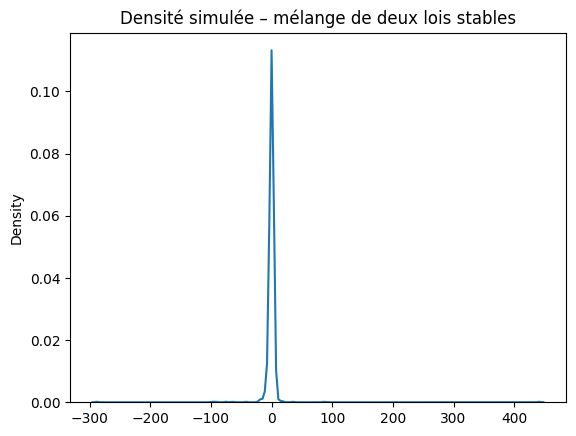

In [ ]:
from Mixstable.generate_sample import generate_mixture_data
import seaborn as sns
import matplotlib.pyplot as plt

data, _ = generate_mixture_data(2,1000)
sns.kdeplot(data, bw_adjust=0.5)
plt.title("Densité simulée – mélange de deux lois stables")
plt.show()


In [ ]:
from Mixstable.generate_sample import generate_mixture_data
import pandas as pd

rows = []
for seed in range(10):
    data, params = generate_mixture_data(2,1000, seed=seed)
    row = {"seed": seed, **params[0], **params[1]}
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_latex("table_simu_summary.tex", index=False)


true_params before ensure_list_of_dicts: <class 'list'> [{'alpha': 1.5414257349537008, 'beta': 0.3213726274423696, 'gamma': 0.8148866927764445, 'delta': -0.08913913012859798, 'pi': np.float64(0.5579971954480097)}, {'alpha': 1.7139482783077535, 'beta': -0.38776689021280797, 'gamma': 0.7804345813258748, 'delta': 0.6799493668763148, 'pi': np.float64(0.44200280455199026)}]
true_params after ensure_list_of_dicts: <class 'list'> [{'alpha': 1.5414257349537008, 'beta': 0.3213726274423696, 'gamma': 0.8148866927764445, 'delta': -0.08913913012859798, 'pi': np.float64(0.5579971954480097)}, {'alpha': 1.7139482783077535, 'beta': -0.38776689021280797, 'gamma': 0.7804345813258748, 'delta': 0.6799493668763148, 'pi': np.float64(0.44200280455199026)}]
est1 raw output: <class 'dict'> {'alpha': np.float64(1.72190642398209), 'beta': np.float64(-0.048060780916988004), 'gamma': np.float64(0.9028769227055676), 'delta': np.float64(0.16702610242225985)}
est_params1 after ensure_list_of_dicts: <class 'list'> [{'a

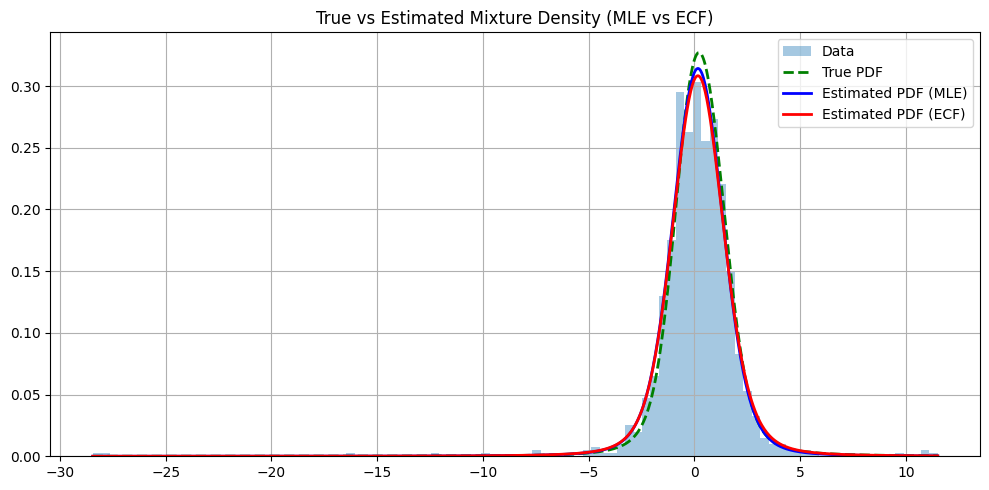

In [ ]:
# Dans Streamlit : utiliser Plotly
# En version script :
from Mixstable.visualization import plot_fit_vs_true_methods
from Mixstable.generate_sample import generate_mixture_data

data, true_params = generate_mixture_data(2,1000)

plot_fit_vs_true_methods(data, true_params, method1="MLE", method2="ECF")

In [8]:
r_packages = {
    "libstable4u": "Estimation de lois stables (MLE)",
    "optim": "Optimisation des log-vraisemblances",
    "ecf.R": "Régressions ECF pour α et β",
    "MASS": "Outils statistiques de base",
    "stats": "Modèles linéaires, densité"
}

import pandas as pd
df_r_pkgs = pd.DataFrame(list(r_packages.items()), columns=["Package", "Fonction principale"])
df_r_pkgs.to_latex("table_r_packages.tex", index=False)


Iteration 0: Log-Likelihood = -1000.178534
Iteration 1: Log-Likelihood = -1000.069730
Iteration 2: Log-Likelihood = -999.956202
Iteration 3: Log-Likelihood = -999.950820
Iteration 4: Log-Likelihood = -999.748243
Iteration 5: Log-Likelihood = -999.748243
Iteration 6: Log-Likelihood = -999.748243
Iteration 7: Log-Likelihood = -999.748243
Iteration 8: Log-Likelihood = -999.748243
Iteration 9: Log-Likelihood = -999.748243
Iteration 10: Log-Likelihood = -999.748243
Iteration 11: Log-Likelihood = -999.748243
Iteration 12: Log-Likelihood = -999.748243
Iteration 13: Log-Likelihood = -999.748243
Iteration 14: Log-Likelihood = -999.748243
Iteration 15: Log-Likelihood = -999.748243
Iteration 16: Log-Likelihood = -999.748243
Iteration 17: Log-Likelihood = -999.748243
Iteration 18: Log-Likelihood = -999.748243
Iteration 19: Log-Likelihood = -999.748243
Iteration 20: Log-Likelihood = -999.748243
Iteration 21: Log-Likelihood = -999.748243
Iteration 22: Log-Likelihood = -999.748243
Iteration 23: Log-L

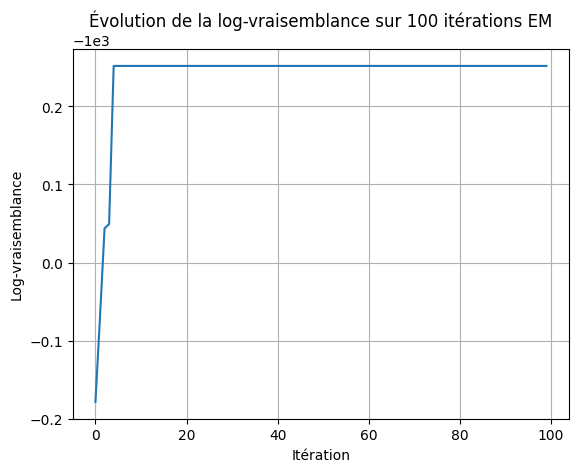

In [ ]:
from Mixstable.generate_sample import generate_mixture_data
import matplotlib.pyplot as plt
from Mixstable.mle import fit_alpha_stable_mle
from sklearn.cluster import KMeans
from Mixstable.utils import r_stable_pdf

def em_fit_alpha_stable_mixture(data, max_iter=100, tol=None, return_trace=False):
    """
    EM algorithm to fit a mixture of two alpha-stable distributions.

    Parameters:
        data (array-like): Input data.
        max_iter (int): Maximum number of iterations (default: 100).
        tol (float or None): Convergence tolerance. If None, disables early stopping.
        return_trace (bool): If True, returns the responsibilities and log-likelihood trace.

    Returns:
        If return_trace:
            params1, params2, w, responsibilities_trace, log_likelihoods
        Else:
            params1, params2, w
    """
    if len(data) < 2:
        raise ValueError("Input data must contain at least two points.")

    def fit_alpha_stable_mle_safe(data):
        try:
            params = fit_alpha_stable_mle(data)
            alpha = np.clip(params[0], 0.1, 1.999)
            return (alpha, *params[1:])
        except Exception as e:
            print(f"[Warning] MLE failed: {e}")
            return (1.5, 0, 1, 0)

    # Initialize clusters using KMeans
    kmeans = KMeans(n_clusters=2, random_state=134).fit(data.reshape(-1, 1))
    labels = kmeans.labels_

    # Initial parameter estimation
    params1 = fit_alpha_stable_mle_safe(data[labels == 0])
    params2 = fit_alpha_stable_mle_safe(data[labels == 1])
    w = np.mean(labels == 0)

    responsibilities_trace = []
    log_likelihoods = []

    prev_log_likelihood = None

    for iteration in range(max_iter):
        # E-step: Compute responsibilities
        pdf1 = np.maximum(r_stable_pdf(data, *params1), 1e-300)
        pdf2 = np.maximum(r_stable_pdf(data, *params2), 1e-300)
        responsibilities = np.vstack([w * pdf1, (1 - w) * pdf2]).T
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # Store traces if requested
        if return_trace:
            responsibilities_trace.append(responsibilities.copy())

        # M-step: Update parameters
        labels = np.argmax(responsibilities, axis=1)
        w = np.mean(labels == 0)

        if np.sum(labels == 0) >= 2:
            params1 = fit_alpha_stable_mle_safe(data[labels == 0])
        if np.sum(labels == 1) >= 2:
            params2 = fit_alpha_stable_mle_safe(data[labels == 1])

        # Compute log-likelihood
        total_pdf = w * pdf1 + (1 - w) * pdf2
        new_log_likelihood = np.sum(np.log(total_pdf))
        if return_trace:
            log_likelihoods.append(new_log_likelihood)

        print(f"Iteration {iteration}: Log-Likelihood = {new_log_likelihood:.6f}")

        # Check for convergence (only if tol is not None)
        if tol is not None and prev_log_likelihood is not None:
            if abs(new_log_likelihood - prev_log_likelihood) / (abs(new_log_likelihood) + 1e-12) < tol:
                print("Converged.")
                break
        prev_log_likelihood = new_log_likelihood

    if return_trace:
        return params1, params2, w, responsibilities_trace, log_likelihoods
    else:
        return params1, params2, w


# Générer des données sûres
data, _ = generate_mixture_data(K=2, N=500, seed=42)

# Lancer l’EM pour 100 itérations sans tolérance de convergence
_, _, _, _, log_likelihoods = em_fit_alpha_stable_mixture(data, max_iter=100, tol=None, return_trace=True)

# Tracer la courbe
plt.plot(log_likelihoods)
plt.xlabel("Itération")
plt.ylabel("Log-vraisemblance")
plt.title("Évolution de la log-vraisemblance sur 100 itérations EM")
plt.grid(True)
plt.show()


In [ ]:
from Mixstable.mcculloch import build_mcculloch_interpolators, generate_mcculloch_table
from Mixstable.simulations import compare_estimators_on_simulations  
import numpy as np

alpha_grid = np.linspace(0.1, 2.0, 100)
beta_grid = np.linspace(-1.0, 1.0, 100)
# Construire les interpolateurs
interp_alpha, interp_beta = build_mcculloch_interpolators(generate_mcculloch_table(alpha_grid, beta_grid, size=100_000, seed=42))

# Appeler la fonction principale avec les interpolateurs
df_results = compare_estimators_on_simulations(n_samples=1000,n_runs=30,interp_alpha=interp_alpha,interp_beta=interp_beta)

# Résumé des performances
summary = df_results.groupby("method").agg(["mean", "std"])
summary.to_latex("table_performance_summary.tex")


In [ ]:
import numpy as np
from Mixstable.testing_data import analyse_stable_distribution
# Load your data

x = np.random.standard_cauchy(1000)  # or use: pd.read_csv("mydata.csv")["IntervalleSeriel"]
x = x[(x > -25) & (x < 25)]  # trim extremes if needed
result_text= analyse_stable_distribution(x, filename="serial_interval_result")
print("Ran OK:", result_text)




Ran OK: ## 📊 Stability Analysis Results

### Dataset Summary
- **Sample size:** 979
- **Skewness:** -0.351
- **Kurtosis:** 15.758  
- **QCV Statistic:** 77.081

### 🧪 Normality Tests

#### Shapiro-Wilk Test
- **Statistic:** 0.7340
- **p-value:** 0.0000
- **Result:** ⛔ Non-normal

#### Anderson-Darling Test  
- **Statistic:** 77.0750
- **Critical value (5%):** 0.7840
- **Result:** ⛔ Non-normal

### 📈 Estimated Stable Parameters
- **α (tail):** 1.069
- **β (skewness):** -0.156
- **γ (scale):** 0.886
- **δ (location):** 0.031

### 🎯 Final Verdict

✅ **Distribution probablement α-stable** (non normale, queue lourde)


In [ ]:
import contextvars
from Mixstable.testing_data import analyse_stable_distribution
import numpy as np

x = np.random.randn(100)

ctx = contextvars.copy_context()
result_text = ctx.run(analyse_stable_distribution, x, "serial_interval_result")
print("Ran OK:", result_text)


Ran OK: ## 📊 Stability Analysis Results

### Dataset Summary
- **Sample size:** 100
- **Skewness:** -0.170
- **Kurtosis:** 3.255  
- **QCV Statistic:** 2.229

### 🧪 Normality Tests

#### Shapiro-Wilk Test
- **Statistic:** 0.9918
- **p-value:** 0.8042
- **Result:** ✅ Normal

#### Anderson-Darling Test  
- **Statistic:** 0.2116
- **Critical value (5%):** 0.7590
- **Result:** ✅ Normal

### 📈 Estimated Stable Parameters
- **α (tail):** 1.943
- **β (skewness):** -1.000
- **γ (scale):** 0.715
- **δ (location):** 0.032

### 🎯 Final Verdict

⛔ **Distribution probablement pas α-stable**


In [ ]:
import contextvars
from Mixstable.testing_data import analyse_stable_distribution
import numpy as np

x = np.random.randn(100)

ctx = contextvars.copy_context()
result_text = ctx.run(analyse_stable_distribution, x, "serial_interval_result")
print("Ran OK:", result_text)